In [58]:
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt 
import warnings as wn
from sklearn.preprocessing import MinMaxScaler
from mlxtend.frequent_patterns import apriori, association_rules
from pymining import seqmining
from prefixspan import PrefixSpan
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from scipy.special import inv_boxcox
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler #To convert data to array

import warnings as wn
wn.filterwarnings("ignore")
sns.set_style("darkgrid")

In [2]:
DateInfo = pd.read_csv(r'DateInfo.csv')
DateInfo_df = pd.DataFrame(DateInfo)

In [3]:
# Return first 5 elements of data
DateInfo_df.head()

,CALENDAR_DATE,YEAR,HOLIDAY,IS_WEEKEND,IS_SCHOOLBREAK,AVERAGE_TEMPERATURE,IS_OUTDOOR
0,1/1/12,2012,New Year,1,0,24.8,0
1,1/2/12,2012,New Year,0,0,24.8,0
2,1/3/12,2012,New Year,0,0,32.0,1
3,1/4/12,2012,NaN,0,0,32.0,1
4,1/5/12,2012,NaN,0,0,24.8,0


In [4]:
# Return last 5 elements of data
print(DateInfo_df.tail())

     CALENDAR_DATE  YEAR HOLIDAY  IS_WEEKEND  IS_SCHOOLBREAK  \
1344        9/6/15  2015     NaN           1               0   
1345        9/7/15  2015     NaN           0               0   
1346        9/8/15  2015     NaN           0               0   
1347        9/9/15  2015     NaN           0               0   
1348       9/10/15  2015     NaN           0               0   

      AVERAGE_TEMPERATURE  IS_OUTDOOR  
1344                 75.2           1  
1345                 77.0           1  
1346                 73.4           1  
1347                 71.6           1  
1348                 73.4           1  


In [5]:
# info of our data
# Print the name columns of df & Print ncol and nrow
print(DateInfo_df.info(),"\n")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1349 entries, 0 to 1348
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CALENDAR_DATE        1349 non-null   object 
 1   YEAR                 1349 non-null   int64  
 2   HOLIDAY              105 non-null    object 
 3   IS_WEEKEND           1349 non-null   int64  
 4   IS_SCHOOLBREAK       1349 non-null   int64  
 5   AVERAGE_TEMPERATURE  1349 non-null   float64
 6   IS_OUTDOOR           1349 non-null   int64  
dtypes: float64(1), int64(4), object(2)
memory usage: 73.9+ KB
None 



In [6]:
#Making sure the data is clean
#Checking the possibility of data containing empty cells
cols = DateInfo_df.columns
DateInfo_df[cols].isnull().sum()

CALENDAR_DATE             0
YEAR                      0
HOLIDAY                1244
IS_WEEKEND                0
IS_SCHOOLBREAK            0
AVERAGE_TEMPERATURE       0
IS_OUTDOOR                0
dtype: int64

In [7]:
DateInfo_df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
1344    False
1345    False
1346    False
1347    False
1348    False
Length: 1349, dtype: bool

In [8]:
DateInfo_df.CALENDAR_DATE = pd.to_datetime(DateInfo_df.CALENDAR_DATE)
DateInfo_df

,CALENDAR_DATE,YEAR,HOLIDAY,IS_WEEKEND,IS_SCHOOLBREAK,AVERAGE_TEMPERATURE,IS_OUTDOOR
0,2012-01-01,2012,New Year,1,0,24.8,0
1,2012-01-02,2012,New Year,0,0,24.8,0
2,2012-01-03,2012,New Year,0,0,32.0,1
3,2012-01-04,2012,NaN,0,0,32.0,1
4,2012-01-05,2012,NaN,0,0,24.8,0
...,...,...,...,...,...,...,...
1344,2015-09-06,2015,NaN,1,0,75.2,1
1345,2015-09-07,2015,NaN,0,0,77.0,1
1346,2015-09-08,2015,NaN,0,0,73.4,1
1347,2015-09-09,2015,NaN,0,0,71.6,1


### Data DateInfo clean

In [9]:
Transaction = pd.read_csv(r'Cafe - Transaction - Store.csv')
Transaction_df = pd.DataFrame(Transaction)
Transaction_df

,STORE,CALENDAR_DATE,PRICE,QUANTITY,SELL_ID,SELL_CATEGORY
0,1,1/1/12,15.50,46,1070,0
1,1,1/1/12,12.73,22,2051,2
2,1,1/1/12,12.75,18,2052,2
3,1,1/1/12,12.60,30,2053,2
4,1,1/2/12,15.50,70,1070,0
...,...,...,...,...,...,...
5399,1,9/9/15,11.26,54,2053,2
5400,1,9/10/15,14.50,96,1070,0
5401,1,9/10/15,12.19,30,2051,2
5402,1,9/10/15,11.50,18,2052,2


In [10]:
# Return first 5 elements of data
Transaction_df.head()

,STORE,CALENDAR_DATE,PRICE,QUANTITY,SELL_ID,SELL_CATEGORY
0,1,1/1/12,15.50,46,1070,0
1,1,1/1/12,12.73,22,2051,2
2,1,1/1/12,12.75,18,2052,2
3,1,1/1/12,12.60,30,2053,2
4,1,1/2/12,15.50,70,1070,0


In [11]:
# info of our data
# Print the name columns of df & Print ncol and nrow
print(Transaction_df.info(),"\n")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5404 entries, 0 to 5403
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   STORE          5404 non-null   int64  
 1   CALENDAR_DATE  5404 non-null   object 
 2   PRICE          5404 non-null   float64
 3   QUANTITY       5404 non-null   int64  
 4   SELL_ID        5404 non-null   int64  
 5   SELL_CATEGORY  5404 non-null   int64  
dtypes: float64(1), int64(4), object(1)
memory usage: 253.4+ KB
None 



In [12]:
#Making sure the data is clean
#Checking the possibility of data containing empty cells
cols = Transaction_df.columns
Transaction_df[cols].isnull().sum()

STORE            0
CALENDAR_DATE    0
PRICE            0
QUANTITY         0
SELL_ID          0
SELL_CATEGORY    0
dtype: int64

In [13]:
Transaction_df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
5399    False
5400    False
5401    False
5402    False
5403    False
Length: 5404, dtype: bool

In [14]:
Transaction_df.CALENDAR_DATE = pd.to_datetime(Transaction_df.CALENDAR_DATE)
Transaction_df

,STORE,CALENDAR_DATE,PRICE,QUANTITY,SELL_ID,SELL_CATEGORY
0,1,2012-01-01,15.50,46,1070,0
1,1,2012-01-01,12.73,22,2051,2
2,1,2012-01-01,12.75,18,2052,2
3,1,2012-01-01,12.60,30,2053,2
4,1,2012-01-02,15.50,70,1070,0
...,...,...,...,...,...,...
5399,1,2015-09-09,11.26,54,2053,2
5400,1,2015-09-10,14.50,96,1070,0
5401,1,2015-09-10,12.19,30,2051,2
5402,1,2015-09-10,11.50,18,2052,2


### Data Transaction clean

In [15]:
SellMetaData = pd.read_csv(r'Cafe - Sell Meta Data.csv')
SellMetaData_df = pd.DataFrame(SellMetaData)
SellMetaData_df

,SELL_ID,SELL_CATEGORY,ITEM_ID,ITEM_NAME
0,1070,0,7821,BURGER
1,3055,0,3052,COFFEE
2,3067,0,5030,COKE
3,3028,0,6249,LEMONADE
4,2051,2,7821,BURGER
5,2051,2,5030,COKE
6,2052,2,7821,BURGER
7,2052,2,6249,LEMONADE
8,2053,2,7821,BURGER
9,2053,2,5030,COKE


In [16]:
# Return first 5 elements of data
SellMetaData_df.head()

,SELL_ID,SELL_CATEGORY,ITEM_ID,ITEM_NAME
0,1070,0,7821,BURGER
1,3055,0,3052,COFFEE
2,3067,0,5030,COKE
3,3028,0,6249,LEMONADE
4,2051,2,7821,BURGER


In [17]:
# Return last 5 elements of data
print(SellMetaData_df.tail())

    SELL_ID  SELL_CATEGORY  ITEM_ID ITEM_NAME
6      2052              2     7821    BURGER
7      2052              2     6249  LEMONADE
8      2053              2     7821    BURGER
9      2053              2     5030      COKE
10     2053              2     3052    COFFEE


In [18]:
# info of our data
# Print the name columns of df & Print ncol and nrow
print(SellMetaData_df.info(),"\n")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   SELL_ID        11 non-null     int64 
 1   SELL_CATEGORY  11 non-null     int64 
 2   ITEM_ID        11 non-null     int64 
 3   ITEM_NAME      11 non-null     object
dtypes: int64(3), object(1)
memory usage: 480.0+ bytes
None 



In [19]:
#Making sure the data is clean
#Checking the possibility of data containing empty cells
cols = SellMetaData_df.columns
SellMetaData_df[cols].isnull().sum()

SELL_ID          0
SELL_CATEGORY    0
ITEM_ID          0
ITEM_NAME        0
dtype: int64

In [20]:
SellMetaData_df.duplicated()

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
dtype: bool

### Data SellMetaData clean

# Merge the datasets

In [21]:
# Merge the datasets on the common column "key"
merged_data = pd.merge(DateInfo_df, Transaction_df , on="CALENDAR_DATE")
cafe_data = pd.merge(merged_data ,SellMetaData_df , on=["SELL_ID",'SELL_CATEGORY' ])

CafeData_df = pd.DataFrame(cafe_data)
CafeData_df

,CALENDAR_DATE,YEAR,HOLIDAY,IS_WEEKEND,IS_SCHOOLBREAK,AVERAGE_TEMPERATURE,IS_OUTDOOR,STORE,PRICE,QUANTITY,SELL_ID,SELL_CATEGORY,ITEM_ID,ITEM_NAME
0,2012-01-01,2012,New Year,1,0,24.8,0,1,15.50,46,1070,0,7821,BURGER
1,2012-01-02,2012,New Year,0,0,24.8,0,1,15.50,70,1070,0,7821,BURGER
2,2012-01-03,2012,New Year,0,0,32.0,1,1,15.50,62,1070,0,7821,BURGER
3,2012-01-04,2012,NaN,0,0,32.0,1,1,15.50,88,1070,0,7821,BURGER
4,2012-01-05,2012,NaN,0,0,24.8,0,1,15.50,104,1070,0,7821,BURGER
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10835,2015-09-09,2015,NaN,0,0,71.6,1,1,11.26,54,2053,2,5030,COKE
10836,2015-09-09,2015,NaN,0,0,71.6,1,1,11.26,54,2053,2,3052,COFFEE
10837,2015-09-10,2015,NaN,0,0,73.4,1,1,11.26,50,2053,2,7821,BURGER
10838,2015-09-10,2015,NaN,0,0,73.4,1,1,11.26,50,2053,2,5030,COKE


In [22]:
# Return first 5 elements of data
CafeData_df.head()

,CALENDAR_DATE,YEAR,HOLIDAY,IS_WEEKEND,IS_SCHOOLBREAK,AVERAGE_TEMPERATURE,IS_OUTDOOR,STORE,PRICE,QUANTITY,SELL_ID,SELL_CATEGORY,ITEM_ID,ITEM_NAME
0,2012-01-01,2012,New Year,1,0,24.8,0,1,15.5,46,1070,0,7821,BURGER
1,2012-01-02,2012,New Year,0,0,24.8,0,1,15.5,70,1070,0,7821,BURGER
2,2012-01-03,2012,New Year,0,0,32.0,1,1,15.5,62,1070,0,7821,BURGER
3,2012-01-04,2012,NaN,0,0,32.0,1,1,15.5,88,1070,0,7821,BURGER
4,2012-01-05,2012,NaN,0,0,24.8,0,1,15.5,104,1070,0,7821,BURGER


In [23]:
# Return last 5 elements of data
print(CafeData_df.tail())

      CALENDAR_DATE  YEAR HOLIDAY  IS_WEEKEND  IS_SCHOOLBREAK  \
10835    2015-09-09  2015     NaN           0               0   
10836    2015-09-09  2015     NaN           0               0   
10837    2015-09-10  2015     NaN           0               0   
10838    2015-09-10  2015     NaN           0               0   
10839    2015-09-10  2015     NaN           0               0   

       AVERAGE_TEMPERATURE  IS_OUTDOOR  STORE  PRICE  QUANTITY  SELL_ID  \
10835                 71.6           1      1  11.26        54     2053   
10836                 71.6           1      1  11.26        54     2053   
10837                 73.4           1      1  11.26        50     2053   
10838                 73.4           1      1  11.26        50     2053   
10839                 73.4           1      1  11.26        50     2053   

       SELL_CATEGORY  ITEM_ID ITEM_NAME  
10835              2     5030      COKE  
10836              2     3052    COFFEE  
10837              2     7821   

In [24]:
# Discription of our data
CafeData_df.describe()

,YEAR,IS_WEEKEND,IS_SCHOOLBREAK,AVERAGE_TEMPERATURE,IS_OUTDOOR,STORE,PRICE,QUANTITY,SELL_ID,SELL_CATEGORY,ITEM_ID
count,10840.000000,10840.000000,10840.00000,10840.000000,10840.000000,10840.0,10840.000000,10840.000000,10840.000000,10840.000000,10840.000000
mean,2013.373432,0.284133,0.20369,56.234244,0.862731,1.0,12.469232,39.928044,1929.375000,1.750000,6330.625000
std,1.070637,0.451021,0.40276,20.224510,0.344147,0.0,1.332332,20.937454,324.829137,0.661468,1696.551284
min,2012.000000,0.000000,0.00000,14.000000,0.000000,1.0,10.120000,8.000000,1070.000000,0.000000,3052.000000
25%,2012.000000,0.000000,0.00000,35.600000,1.000000,1.0,11.480000,24.000000,2051.000000,2.000000,5030.000000
50%,2013.000000,0.000000,0.00000,60.800000,1.000000,1.0,12.460000,34.000000,2052.000000,2.000000,7035.000000
75%,2014.000000,1.000000,0.00000,75.200000,1.000000,1.0,12.850000,50.000000,2053.000000,2.000000,7821.000000
max,2015.000000,1.000000,1.00000,87.800000,1.000000,1.0,16.500000,124.000000,2053.000000,2.000000,7821.000000


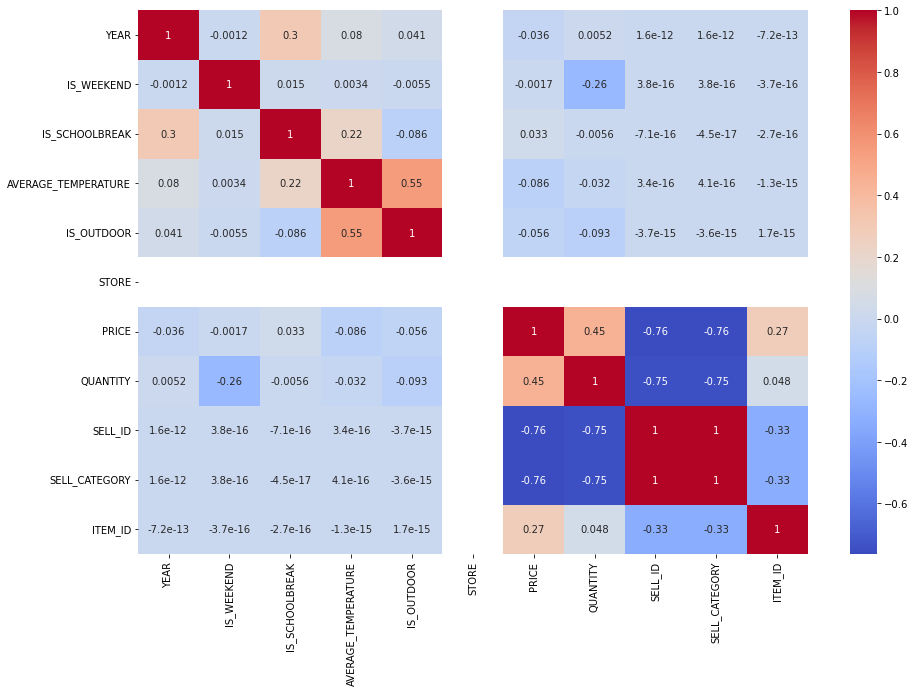

In [25]:
fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(111)

corr_matrix = CafeData_df.corr()

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")

plt.show()

 notes:
from the correlation matrix we know the correlation(positive or negative)and non crrelation between the data The correlation 

1.- There is a linear correlation among them.

2.- There are nulls in the feature holiday.

3.-between (AVERAGE_TEMPERATURE,YEAR)is positive crrelation=0.08 The correlation 

4.-between (SELL_ID,PRICE)is negative crrelation=-0.76 

5.-Between (YEAR,IS_WEEKEND)the correlation coefficient is very close to zero, indicating that there is almost no correlation between the two variables

6.- QTY is highly linear correlated to sell_id, sell_cat 

7.- week negative crrelation is_weekend and price ,and so on..


# Cluster

In [26]:
# Drop irrelevant variables
droped_data = CafeData_df.drop(['STORE','SELL_ID','ITEM_ID','ITEM_NAME','CALENDAR_DATE'], axis=1)

# Convert categorical variables to numerical using one-hot encoding
data = pd.get_dummies(droped_data)

# Standardize the numerical variables
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)
data_scaled


array([[-1.28287668,  1.58728716, -0.50575923, ..., 11.5974135 ,
        -0.09452629, -0.04710557],
       [-1.28287668, -0.63000573, -0.50575923, ..., 11.5974135 ,
        -0.09452629, -0.04710557],
       [-1.28287668, -0.63000573, -0.50575923, ..., 11.5974135 ,
        -0.09452629, -0.04710557],
       ...,
       [ 1.51932305, -0.63000573, -0.50575923, ..., -0.08622612,
        -0.09452629, -0.04710557],
       [ 1.51932305, -0.63000573, -0.50575923, ..., -0.08622612,
        -0.09452629, -0.04710557],
       [ 1.51932305, -0.63000573, -0.50575923, ..., -0.08622612,
        -0.09452629, -0.04710557]])

In [27]:
#Apply DBSCAN clustering
dbscan = DBSCAN(eps=0.5, min_samples=50)
clusters = dbscan.fit_predict(data_scaled)

#Analyze the resulting clusters
n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
print(f"Number of clusters: {n_clusters}")
print(f"Cluster sizes: {pd.Series(clusters).value_counts()}") 

Number of clusters: 40
Cluster sizes: -1     4020
 3      900
 16     683
 6      372
 21     362
 7      324
 9      272
 10     259
 22     257
 31     243
 17     219
 35     192
 20     188
 12     148
 39     138
 8      136
 36     129
 1      126
 33     123
 34     111
 38     105
 4      104
 23     103
 32     102
 11     101
 26      92
 2       87
 18      84
 27      82
 30      72
 19      70
 28      70
 0       69
 14      68
 24      68
 5       67
 37      62
 15      60
 13      60
 25      60
 29      52
dtype: int64


# Association Rule

In [28]:
# Select columns to use for association rule mining 
#only the catigoral data
columns_for_ar = ["HOLIDAY", "IS_WEEKEND", "IS_SCHOOLBREAK", "IS_OUTDOOR", "STORE", "ITEM_NAME"]
# Create one-hot encoded DataFrame
#get_dummies() function converts each categorical column in data[columns_for_ar] into a set of binary (0 or 1) columns
onehot_data = pd.get_dummies(CafeData_df[columns_for_ar])

# Generate frequent itemsets
frequent_itemsets = apriori(onehot_data, min_support=0.01, use_colnames=True)
#we use the association_rules() function from the mlxtend library to generate association rules from the frequent itemsets.
# metric="lift" use to measures how much more likely the consequent of a rule is given the antecedent
#if ilft=1 means that the antecedent and consequent are independent, while a value greater than 1 means that they are positively correlated
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)

# Print the results
print(rules.head())

          antecedents       consequents  antecedent support  \
0        (IS_WEEKEND)  (IS_SCHOOLBREAK)            0.284133   
1    (IS_SCHOOLBREAK)      (IS_WEEKEND)            0.203690   
2             (STORE)      (IS_WEEKEND)            1.000000   
3        (IS_WEEKEND)           (STORE)            0.284133   
4  (ITEM_NAME_BURGER)      (IS_WEEKEND)            0.500000   

   consequent support   support  confidence      lift  leverage  conviction  \
0            0.203690  0.060517    0.212987  1.045643  0.002642    1.011813   
1            0.284133  0.060517    0.297101  1.045643  0.002642    1.018450   
2            0.284133  0.284133    0.284133  1.000000  0.000000    1.000000   
3            1.000000  0.284133    1.000000  1.000000  0.000000         inf   
4            0.284133  0.142066    0.284133  1.000000  0.000000    1.000000   

   zhangs_metric  
0       0.060976  
1       0.054816  
2       0.000000  
3       0.000000  
4       0.000000  


C:\Users\Admin\anaconda3\lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:110: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


# Sequential Pattern

In [30]:
# Select the HOLIDAY, SELL_CATEGORY,PRICE and ITEM_NAME columns as the sequence to mine
sequence = CafeData_df[["HOLIDAY","SELL_CATEGORY","PRICE","ITEM_NAME"]].apply(tuple, axis=1).tolist()
# Perform sequential pattern discovery using prefixspan
ps = PrefixSpan(sequence)
#the code is likely using it to identify patterns of data that occur frequently in a dataset. The number "2" passed as an argument to the "frequent
#looking for patterns that occur at least two times in the dataset
patterns = ps.frequent(2)

# Print the frequent patterns
df_patterns= pd.DataFrame(patterns)
df_patterns

,0,1
0,80,[New Year]
1,10,"[New Year, 0]"
2,9,"[New Year, 0, 15.5]"
3,9,"[New Year, 0, 15.5, BURGER]"
4,10,"[New Year, 0, BURGER]"
...,...,...
1248,120,"[10.81, COFFEE]"
1249,87,[11.26]
1250,29,"[11.26, BURGER]"
1251,29,"[11.26, COKE]"


# percentage change in quantity demanded and price

In [31]:
# Create a linear regression model
X = CafeData_df['PRICE']
X = sm.add_constant(X)
y = CafeData_df['QUANTITY']
model = sm.OLS(y, X).fit()

# Calculate the price elasticity
price_coeff = model.params['PRICE']
avg_price = np.mean(CafeData_df['PRICE'])
avg_quantity = np.mean(CafeData_df['QUANTITY'])
price_elasticity = price_coeff * (avg_price / avg_quantity)

# Print the results
print("Price elasticity:", price_elasticity)

Price elasticity: 2.185646352692894


If the price elasticity of demand is greater than 1, meaning that a change in price will have a relatively large effect on the quantity demanded. If the price elasticity of demand is less than 1, meaning that a change in price will have a relatively small effect on the quantity demanded.

form the run we know that Price elasticity: 2.185646352692894 which mean that there is large effect on the quantity demanded

# Visualization work and extraction of results from it

Text(0.5, 1.0, 'Bubble Chart')

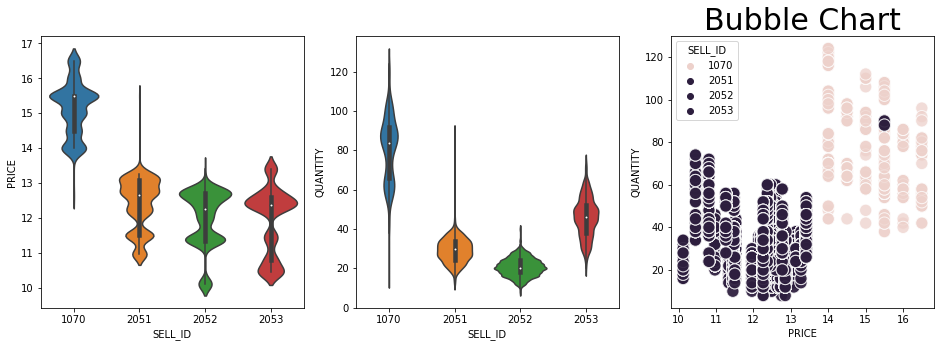

In [32]:
fig,axis=plt.subplots(nrows=1,ncols=3 , figsize=(16,5))
ax = sns.violinplot(data = CafeData_df,x='SELL_ID',y='PRICE' ,ax=axis[0])
plt.title('Price by sell id')
ax =sns.violinplot(data = CafeData_df,x='SELL_ID',y='QUANTITY',ax=axis[1])
plt.title('Qulitty by sell id')
ax =sns.scatterplot(data=CafeData_df,x='PRICE',y='QUANTITY',hue="SELL_ID",s=150,alpha=0.75 ,ax=axis[2])
plt.title("Bubble Chart",size=30)

Of this 3 charts we can observe that:

1.- The 1070 has a different set of price and quantity (more expensive and more quantity) than the combos.

2.- 1070 has different price distribution but the others are similar.

3.- The 1070 quantity is more spread. All products have different qty distribution.

4.- Split by sell_id would be a good idea to optimize the prices since they have different distributions

# Transformations

In [36]:
def split_and_boxcox(dataset,feature,SELL_ID):
    dataset = dataset[dataset['SELL_ID'] == SELL_ID].copy()
    params=[]
    for x in feature:
        feature_box= x+"_boxcox"
        dataset[feature_box],params_x = stats.boxcox(dataset[x]) 
        params.append(params_x)
    return dataset,params

In [37]:
df = CafeData_df

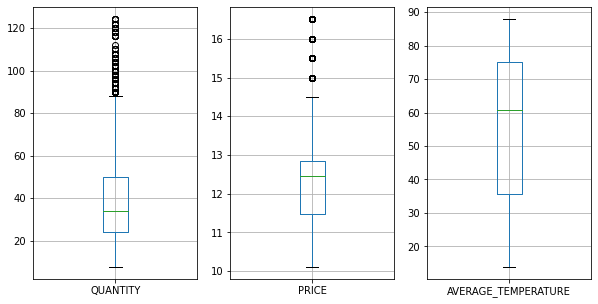

In [38]:
#display the out layer
fig,axis=plt.subplots(nrows=1,ncols=3 , figsize=(10,5))
ax=df.boxplot('QUANTITY',ax=axis[0])
ax=df.boxplot('PRICE',ax=axis[1])
ax=df.boxplot('AVERAGE_TEMPERATURE',ax=axis[2])
plt.show()


I used the box cox transformation to give a more symmetrical shape to both features.

Now I will use the z-score to scale down the numerical features


In [42]:

df['HOLIDAY'].fillna('None', inplace=True)  # Replace missing values with 'None'
df = pd.get_dummies(df, columns=['HOLIDAY'])

scaler_price = StandardScaler()
scaler_qty = StandardScaler()
scaler_avg = StandardScaler()
#Product 1070 (I will optimize the product 1070, for the rest I would follow the same procedure)
df_1070,param_1070 = split_and_boxcox(df,['QUANTITY','PRICE','AVERAGE_TEMPERATURE'],1070)
df_1070['QTY_T'] = scaler_qty.fit_transform(df_1070[['QUANTITY']])
df_1070['PRICE_T'] = scaler_price.fit_transform(df_1070[['PRICE']])
df_1070['AVG_TEMPERATURE_T'] = scaler_avg.fit_transform(df_1070[['AVERAGE_TEMPERATURE']])
df_1070



,CALENDAR_DATE,YEAR,IS_WEEKEND,IS_SCHOOLBREAK,AVERAGE_TEMPERATURE,IS_OUTDOOR,STORE,PRICE,QUANTITY,SELL_ID,...,HOLIDAY_New Year,HOLIDAY_None,HOLIDAY_Qing Ming Festival,HOLIDAY_WWII Celebration,QUANTITY_boxcox,PRICE_boxcox,AVERAGE_TEMPERATURE_boxcox,QTY_T,PRICE_T,AVG_TEMPERATURE_T
0,2012-01-01,2012,1,0,24.8,0,1,15.5,46,1070,...,1,0,0,0,115.860969,338.448614,24.878226,-2.117184,0.449242,-1.554336
1,2012-01-02,2012,0,0,24.8,0,1,15.5,70,1070,...,1,0,0,0,201.748349,338.448614,24.878226,-0.678536,0.449242,-1.554336
2,2012-01-03,2012,0,0,32.0,1,1,15.5,62,1070,...,1,0,0,0,171.889872,338.448614,32.546570,-1.158085,0.449242,-1.198316
3,2012-01-04,2012,0,0,32.0,1,1,15.5,88,1070,...,0,1,0,0,272.812809,338.448614,32.546570,0.400450,0.449242,-1.198316
4,2012-01-05,2012,0,0,24.8,0,1,15.5,104,1070,...,0,1,0,0,339.987439,338.448614,24.878226,1.359549,0.449242,-1.554336
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1350,2015-09-06,2015,1,0,75.2,1,1,14.5,94,1070,...,0,1,0,0,297.588458,287.313930,79.088521,0.760112,-0.872804,0.937804
1351,2015-09-07,2015,0,0,77.0,1,1,14.5,98,1070,...,0,1,0,0,314.386051,287.313930,81.041649,0.999887,-0.872804,1.026809
1352,2015-09-08,2015,0,0,73.4,1,1,14.5,90,1070,...,0,1,0,0,281.014144,287.313930,77.136274,0.520338,-0.872804,0.848799
1353,2015-09-09,2015,0,0,71.6,1,1,14.5,96,1070,...,0,1,0,0,305.959748,287.313930,75.184929,0.880000,-0.872804,0.759794


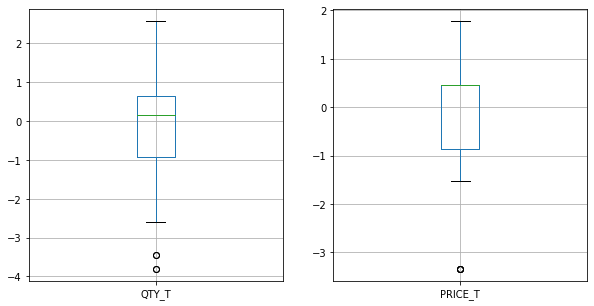

In [43]:
#display the out layer
fig, axis = plt.subplots(ncols=2, nrows=1, figsize=(10,5))
ax = df_1070.boxplot('QTY_T', ax=axis[0])
ax = df_1070.boxplot('PRICE_T', ax=axis[1])



 After the transformations the outliers had dissapear.


In [44]:
# Label encode year
encoder = LabelEncoder()
df_1070['YEAR']  = encoder.fit_transform(df_1070['YEAR'] )
df_1070

,CALENDAR_DATE,YEAR,IS_WEEKEND,IS_SCHOOLBREAK,AVERAGE_TEMPERATURE,IS_OUTDOOR,STORE,PRICE,QUANTITY,SELL_ID,...,HOLIDAY_New Year,HOLIDAY_None,HOLIDAY_Qing Ming Festival,HOLIDAY_WWII Celebration,QUANTITY_boxcox,PRICE_boxcox,AVERAGE_TEMPERATURE_boxcox,QTY_T,PRICE_T,AVG_TEMPERATURE_T
0,2012-01-01,0,1,0,24.8,0,1,15.5,46,1070,...,1,0,0,0,115.860969,338.448614,24.878226,-2.117184,0.449242,-1.554336
1,2012-01-02,0,0,0,24.8,0,1,15.5,70,1070,...,1,0,0,0,201.748349,338.448614,24.878226,-0.678536,0.449242,-1.554336
2,2012-01-03,0,0,0,32.0,1,1,15.5,62,1070,...,1,0,0,0,171.889872,338.448614,32.546570,-1.158085,0.449242,-1.198316
3,2012-01-04,0,0,0,32.0,1,1,15.5,88,1070,...,0,1,0,0,272.812809,338.448614,32.546570,0.400450,0.449242,-1.198316
4,2012-01-05,0,0,0,24.8,0,1,15.5,104,1070,...,0,1,0,0,339.987439,338.448614,24.878226,1.359549,0.449242,-1.554336
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1350,2015-09-06,3,1,0,75.2,1,1,14.5,94,1070,...,0,1,0,0,297.588458,287.313930,79.088521,0.760112,-0.872804,0.937804
1351,2015-09-07,3,0,0,77.0,1,1,14.5,98,1070,...,0,1,0,0,314.386051,287.313930,81.041649,0.999887,-0.872804,1.026809
1352,2015-09-08,3,0,0,73.4,1,1,14.5,90,1070,...,0,1,0,0,281.014144,287.313930,77.136274,0.520338,-0.872804,0.848799
1353,2015-09-09,3,0,0,71.6,1,1,14.5,96,1070,...,0,1,0,0,305.959748,287.313930,75.184929,0.880000,-0.872804,0.759794


# Model (Linear regression analysis )

                            OLS Regression Results                            
Dep. Variable:                  QTY_T   R-squared:                       0.721
Model:                            OLS   Adj. R-squared:                  0.720
Method:                 Least Squares   F-statistic:                     497.6
Date:                Wed, 17 May 2023   Prob (F-statistic):               0.00
Time:                        21:09:45   Log-Likelihood:                -1057.4
No. Observations:                1355   AIC:                             2131.
Df Residuals:                    1347   BIC:                             2173.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 1.3328      0.05

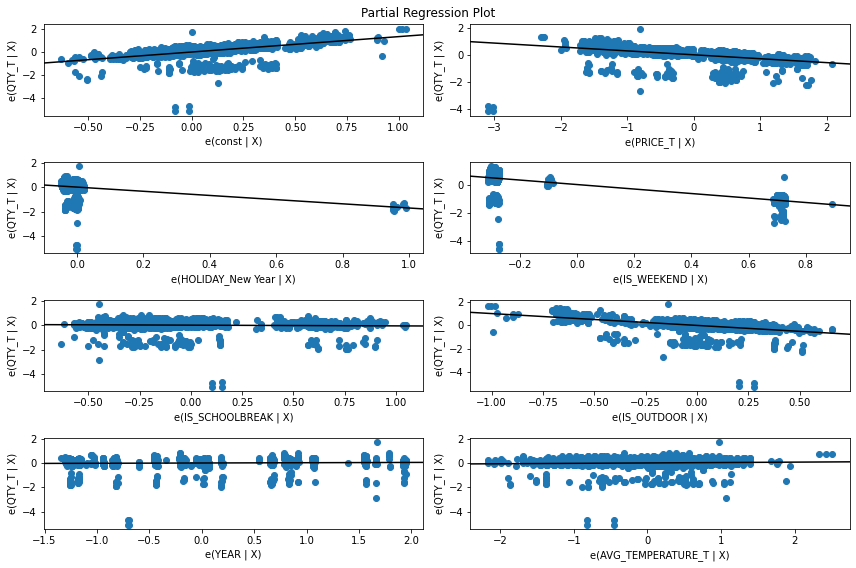

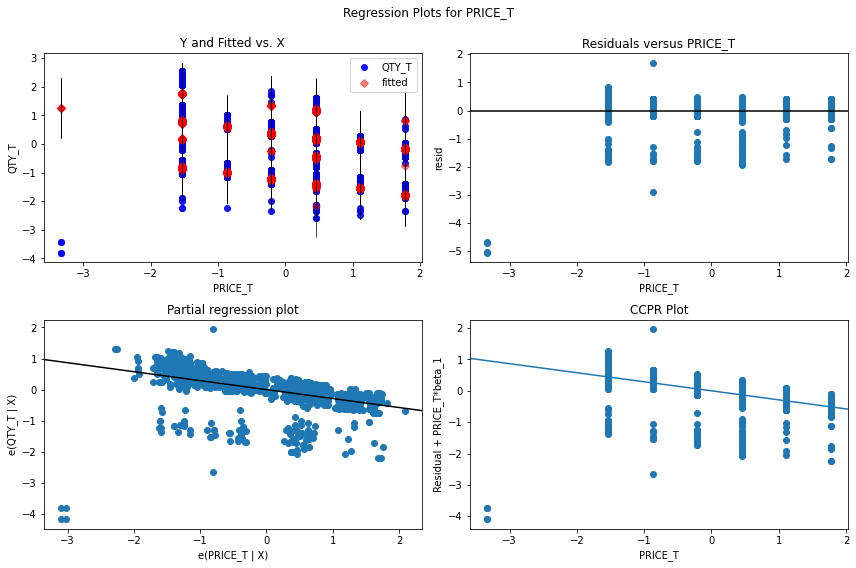

In [56]:
X = df_1070[['PRICE_T', 'HOLIDAY_New Year', 'IS_WEEKEND', 'IS_SCHOOLBREAK', 'IS_OUTDOOR', 'YEAR', 'AVG_TEMPERATURE_T']]
y = df_1070['QTY_T']
X = sm.add_constant(X)  # Add constant term
model = sm.OLS(y, X)

# Fit model and print summary
results = model.fit()
print(results.summary())

# Create partial regression plot
fig = plt.figure(figsize=(12, 8))
fig = sm.graphics.plot_partregress_grid(results, fig=fig)

# Create regression plot for price vs quantity
fig = plt.figure(figsize=(12, 8))
fig = sm.graphics.plot_regress_exog(results, 'PRICE_T', fig=fig)

results:

1.- is_schoolbreak and avg_temperature have a p-value > 0.1 so they don´t affect to the good fit of the model

2.- All features but year has a negative correlation with quantity which indicates that the shop sells more during work days.


### The next step is to remove those features that are not relevant for the model

                            OLS Regression Results                            
Dep. Variable:                  QTY_T   R-squared:                       0.720
Model:                            OLS   Adj. R-squared:                  0.719
Method:                 Least Squares   F-statistic:                     867.5
Date:                Wed, 17 May 2023   Prob (F-statistic):               0.00
Time:                        21:11:22   Log-Likelihood:                -1060.4
No. Observations:                1355   AIC:                             2131.
Df Residuals:                    1350   BIC:                             2157.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                1.2997      0.041  

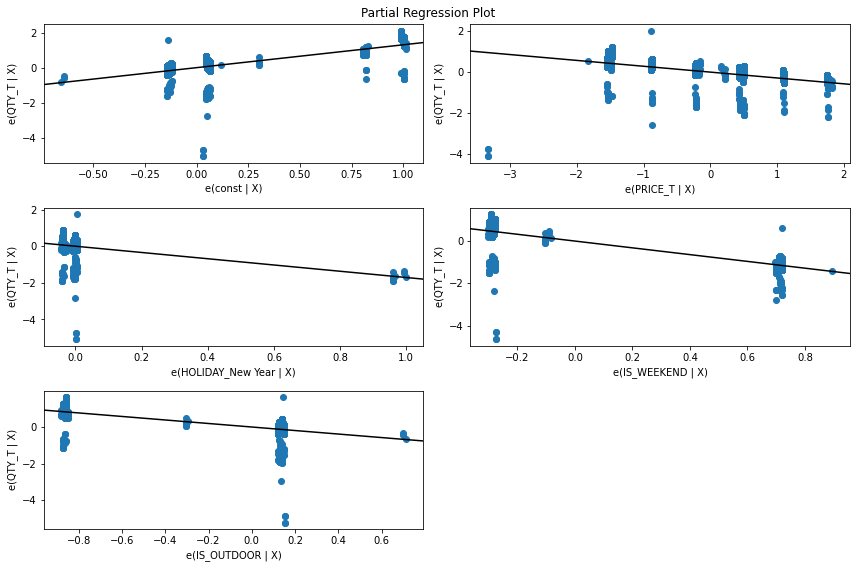

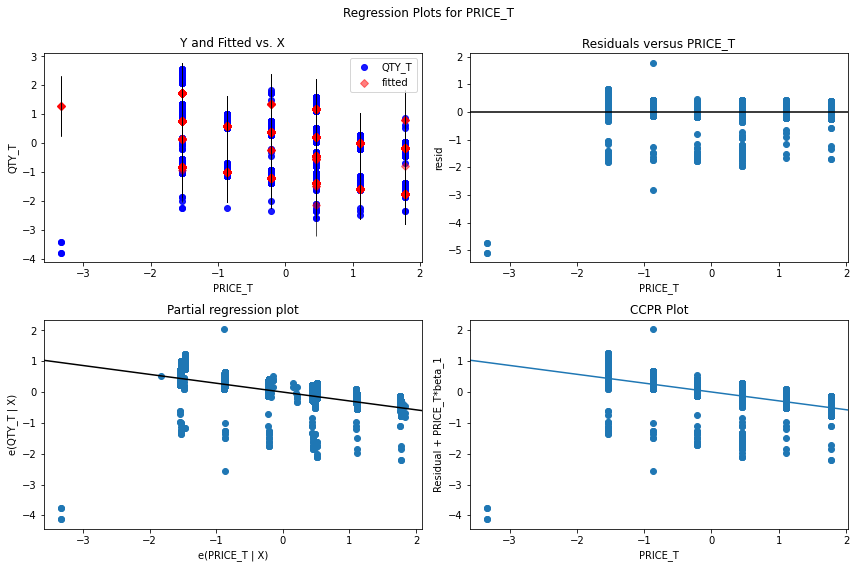

In [57]:

X1 = df_1070[['PRICE_T', 'HOLIDAY_New Year', 'IS_WEEKEND', 'IS_OUTDOOR']]
y1 = df_1070['QTY_T']

X1 = sm.add_constant(X1)  # Add constant term
model1 = sm.OLS(y1, X1)

# Fit model and print summary
results1 = model1.fit()
print(results1.summary())

# Create partial regression plot
fig = plt.figure(figsize=(12, 8))
fig = sm.graphics.plot_partregress_grid(results1, fig=fig)

# Create regression plot for price vs quantity
fig = plt.figure(figsize=(12, 8))
fig = sm.graphics.plot_regress_exog(results1, 'PRICE_T', fig=fig)


# Model (Logistic Regression )

In [50]:
Log_df= CafeData_df

encoder=LabelEncoder()
Log_df['ITEM_NAME']=encoder.fit_transform(Log_df['ITEM_NAME'])
Log_df['HOLIDAY'].fillna('None', inplace=True)  # Replace missing values with 'None'
Log_df = pd.get_dummies(CafeData_df, columns=['HOLIDAY'])

(8672, 4) (2168, 4)
Accuracy: 0.8745387453874539


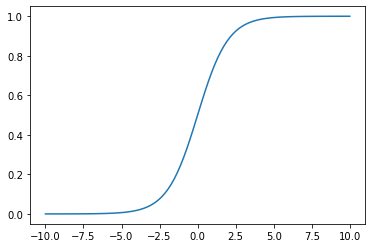

In [51]:
# Prepare the data
X2 = Log_df[["IS_WEEKEND", "IS_SCHOOLBREAK","IS_OUTDOOR","ITEM_NAME"]]
y2= Log_df["SELL_CATEGORY"]
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)
print(X2_train.shape, X2_test.shape)
# Train the model
model = LogisticRegression()
model.fit(X2_train, y2_train)

# Make predictions
y2_pred = model.predict(X2_test)

# Evaluate the model
accuracy = accuracy_score(y2_test, y2_pred)
print("Accuracy:", accuracy)
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

x2 = np.linspace(-10, 10, 100)
y2 = sigmoid(x2)

plt.plot(x2, y2)
plt.show()


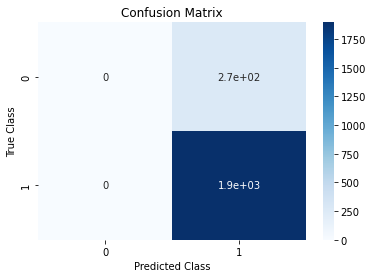

In [52]:
# Visualize the results
cm = confusion_matrix(y2_test, y2_pred)
sns.heatmap(cm, annot=True, cmap="Blues")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix")
plt.show()